<a href="https://colab.research.google.com/github/nitinmaury8-cyber/college_student_performance/blob/main/Zomato_sales_analysis_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'zomato_sales_dataset.csv')
df.head()

,order_id,restaurant_id,restaurant_name,city,cuisine_type,order_date,order_time,customer_id,num_items,is_veg,order_value_inr,discount_percent,distance_km,delivery_time_mins,payment_method,customer_rating,is_cancelled
0,ORD00001,R0017,Urban Corner,Lucknow,Mughlai,2024-04-08,15:26,CUST0681,4,Non-Veg,350.0,20,6.8,32.0,Wallet,3.0,No
1,ORD00002,R0039,Chai Treat,Pune,Fast Food,2024-07-26,11:35,CUST0854,3,Veg,320.0,10,3.0,26.0,UPI,3.0,No
2,ORD00003,R0084,Punjabi Bites,Bangalore,South Indian,2024-06-13,14:29,CUST0453,4,Veg,370.0,0,9.6,37.0,Credit Card,4.0,No
3,ORD00004,R0102,Desi Kitchen,Pune,Desserts,2024-03-27,19:42,CUST0087,4,Veg,680.0,20,0.8,10.0,Debit Card,4.0,No
4,ORD00005,R0097,Bombay Kitchen,Mumbai,Thai,2024-04-30,16:43,CUST0318,6,Veg,920.0,0,0.5,13.0,UPI,4.0,No


In [3]:
df.isnull()
df.isnull().sum()

,0
order_id,0
restaurant_id,0
restaurant_name,0
city,0
cuisine_type,0
order_date,0
order_time,0
customer_id,0
num_items,0
is_veg,0


In [4]:
df.isnull().mean()*100

,0
order_id,0.0
restaurant_id,0.0
restaurant_name,0.0
city,0.0
cuisine_type,0.0
order_date,0.0
order_time,0.0
customer_id,0.0
num_items,0.0
is_veg,0.0


*here i found null values in column (distance_km,customer rating)in the customer rating their are 2% people who don't want to give rating or they forget !*



In [5]:
df.dropna(subset=['customer_rating'],inplace = True)
df.dropna(subset=['distance_km'],inplace = True)

In [6]:
df.isnull().sum()

,0
order_id,0
restaurant_id,0
restaurant_name,0
city,0
cuisine_type,0
order_date,0
order_time,0
customer_id,0
num_items,0
is_veg,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2426 entries, 0 to 2499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            2426 non-null   object 
 1   restaurant_id       2426 non-null   object 
 2   restaurant_name     2426 non-null   object 
 3   city                2426 non-null   object 
 4   cuisine_type        2426 non-null   object 
 5   order_date          2426 non-null   object 
 6   order_time          2426 non-null   object 
 7   customer_id         2426 non-null   object 
 8   num_items           2426 non-null   int64  
 9   is_veg              2426 non-null   object 
 10  order_value_inr     2426 non-null   float64
 11  discount_percent    2426 non-null   int64  
 12  distance_km         2426 non-null   float64
 13  delivery_time_mins  2426 non-null   float64
 14  payment_method      2426 non-null   object 
 15  customer_rating     2426 non-null   float64
 16  is_cancelle

In [8]:
df.describe()

,num_items,order_value_inr,discount_percent,distance_km,delivery_time_mins,customer_rating
count,2426.000000,2426.000000,2426.000000,2426.000000,2426.000000,2426.000000
mean,3.016488,426.431987,14.241550,3.920363,24.866035,3.949299
std,1.429201,266.556206,11.280024,3.367977,9.699686,0.679224
min,1.000000,99.000000,0.000000,0.500000,10.000000,2.000000
25%,2.000000,220.000000,0.000000,1.500000,18.000000,4.000000
50%,3.000000,380.000000,15.000000,2.800000,23.000000,4.000000
75%,4.000000,570.000000,20.000000,5.300000,29.000000,4.000000
max,9.000000,1950.000000,50.000000,20.000000,68.000000,5.000000


*if we see from num_item -> mean=approx(3),mediun = 3,means average order size are 3 max order value is 1950rs but most orders range is (100-500 )rs so their is increase in variation of orders*


In [9]:
df.columns

Index(['order_id', 'restaurant_id', 'restaurant_name', 'city', 'cuisine_type',
       'order_date', 'order_time', 'customer_id', 'num_items', 'is_veg',
       'order_value_inr', 'discount_percent', 'distance_km',
       'delivery_time_mins', 'payment_method', 'customer_rating',
       'is_cancelled'],
      dtype='object')

*their is 6 numerical column and 11 categorical columns*

In [10]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['num_items', 'order_value_inr', 'discount_percent', 'distance_km', 'delivery_time_mins', 'customer_rating']
Categorical Columns: ['order_id', 'restaurant_id', 'restaurant_name', 'city', 'cuisine_type', 'order_date', 'order_time', 'customer_id', 'is_veg', 'payment_method', 'is_cancelled']


In [11]:
top_cuisine_by_city = (
    df.groupby(['city', 'cuisine_type'])['order_value_inr'].sum()
    .reset_index()
    .sort_values(by=['city', 'order_value_inr'], ascending=[True, False])
    .groupby('city').first().reset_index()
)
print(top_cuisine_by_city)

        city  cuisine_type  order_value_inr
0  Ahmedabad  North Indian          35215.0
1  Bangalore          Thai          17318.0
2    Chennai       Mughlai          36493.0
3      Delhi      Desserts          29395.0
4  Hyderabad        Bakery          10740.0
5     Jaipur      Desserts          21668.0
6    Kolkata     Fast Food          17876.0
7    Lucknow       Mughlai          17256.0
8     Mumbai          Thai          28237.0
9       Pune     Fast Food          16147.0


*by this data we find that maximum cuisine type order in which cities*
*from ahmedabad ,north indian cusine have higher order volume*
*similarily in chennai ,mughlai cuisine have higher order volume*

# **DATA VISUALIZATION**

# Sales trend by month/day-of-week/hour → line/bar charts

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df['order_date'] = pd.to_datetime(df['order_date'])
df['order_datetime'] = df['order_date'].astype(str)+' '+df['order_time']
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['month'] = df['order_datetime'].dt.month_name()
df['day_in_week'] = df['order_datetime'].dt.day_name()
df['hour'] = df['order_datetime'].dt.hour


### Sales Trend by Month

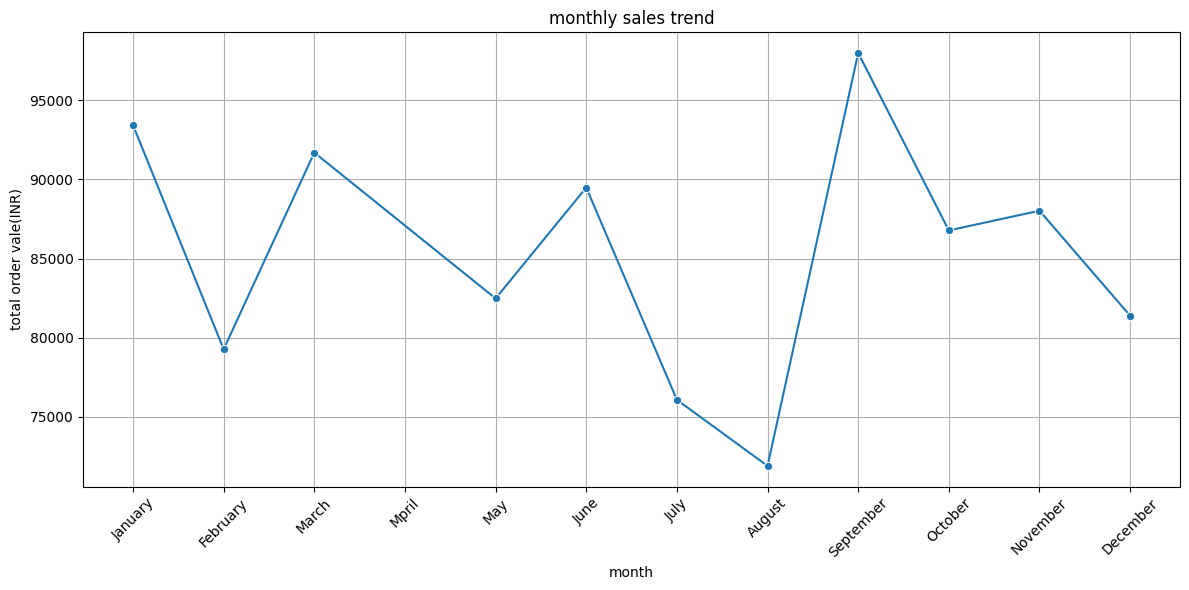

In [13]:
monthly_sales = df.groupby('month')['order_value_inr'].sum().reindex(['January','February','March','Mpril','May','June','July','August','September','October','November','December'])

plt.figure(figsize=(12,6))
sns.lineplot( x = monthly_sales.index,y=monthly_sales.values,marker='o')
plt.title('monthly sales trend')
plt.xlabel('month')
plt.ylabel('total order vale(INR)')
plt.xticks(rotation =45)
plt.grid( True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1590/118372986.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_sales.index, y=daily_sales.values, palette='viridis')


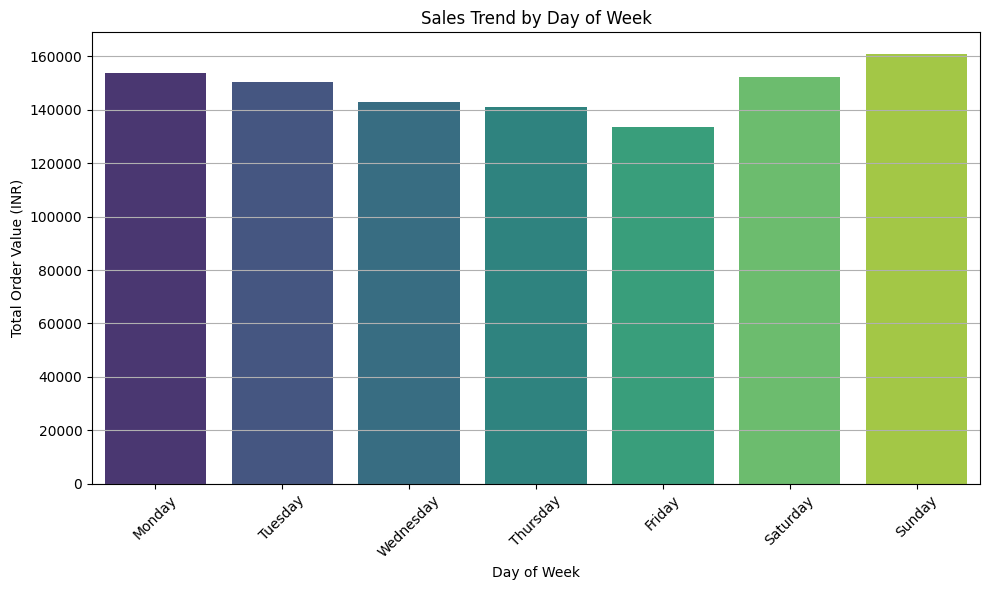

In [14]:
daily_sales = df.groupby('day_in_week')['order_value_inr'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 6))
sns.barplot(x=daily_sales.index, y=daily_sales.values, palette='viridis')
plt.title('Sales Trend by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Order Value (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Sales Trend by Hour of Day

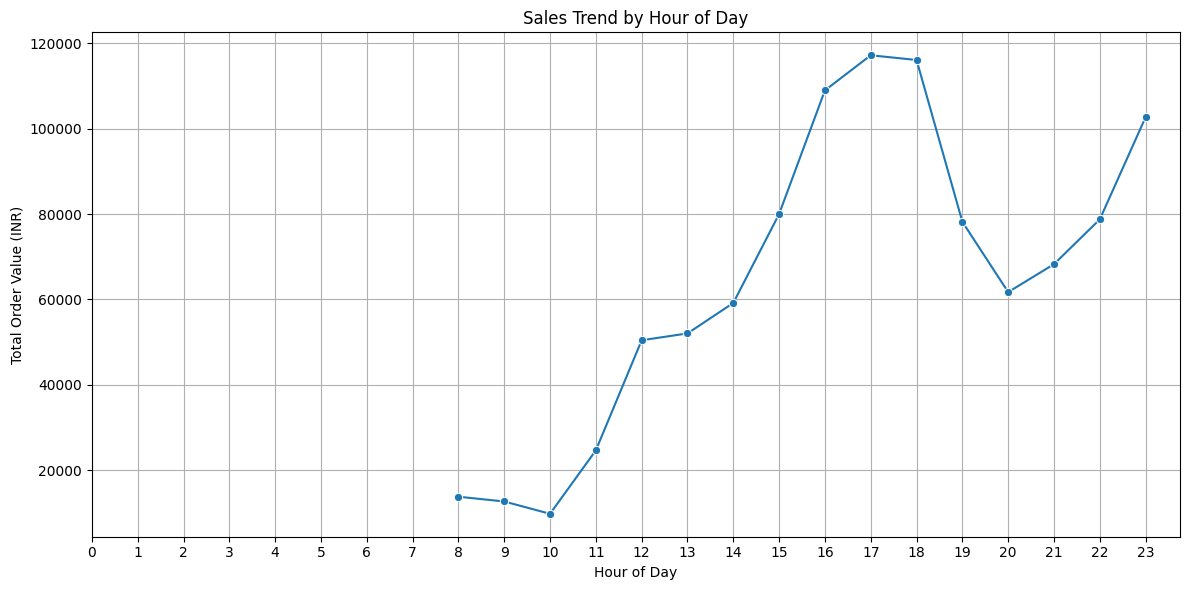

In [15]:
from matplotlib import colors
hourly_sales = df.groupby('hour')['order_value_inr'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o')
plt.title('Sales Trend by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Order Value (INR)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# City-wise and cuisine-wise revenue & order volume

*city wise revenue*

In [16]:
df.groupby('city')['order_value_inr'].sum().sort_values(ascending=False)

,order_value_inr
city,
Delhi,185252.0
Mumbai,155787.0
Ahmedabad,123373.0
Chennai,123064.0
Bangalore,110231.0
Pune,87248.0
Jaipur,75203.0
Hyderabad,68740.0
Lucknow,67306.0


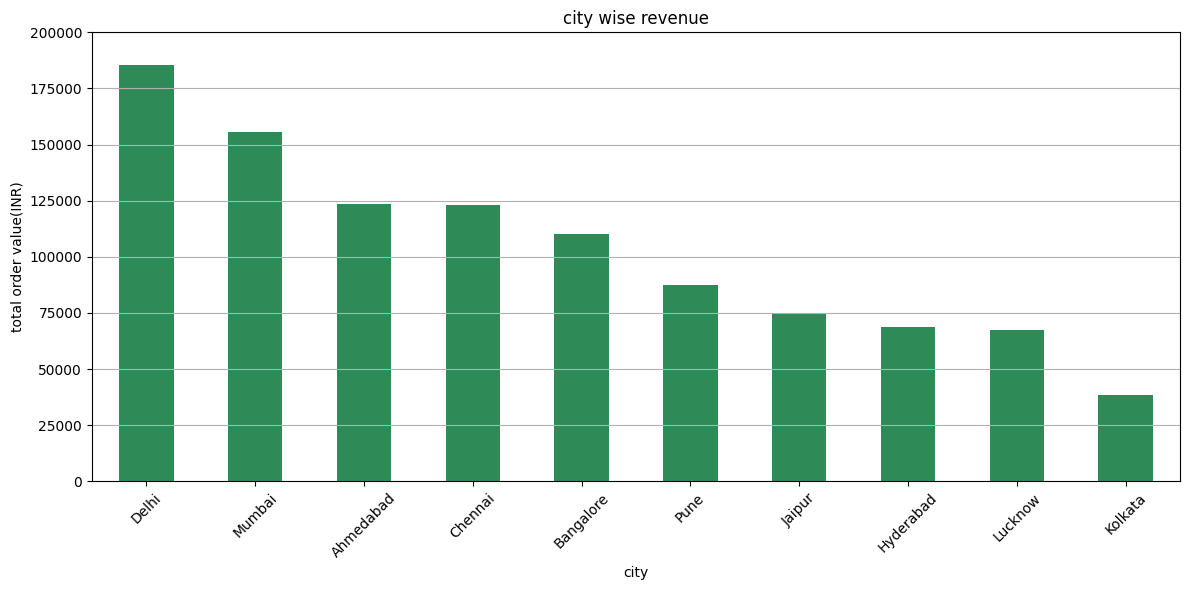

In [17]:
cost_revenue = df.groupby('city')['order_value_inr'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
cost_revenue.plot(kind = 'bar',color ='Seagreen')
plt.xlabel('city')
plt.ylabel('total order value(INR)')
plt.ylim(0,200000)
plt.title('city wise revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

*city wise order volume*

In [18]:
df.groupby('city').size().sort_values(ascending=False)

,0
city,
Delhi,426
Mumbai,373
Chennai,298
Ahmedabad,258
Bangalore,257
Pune,213
Jaipur,174
Lucknow,168
Hyderabad,160


In [19]:
df.groupby('cuisine_type')['num_items'].sum().sort_values(ascending=False)

,num_items
cuisine_type,
Desserts,930
Bakery,872
Thai,752
Italian,684
Fast Food,666
Mughlai,664
North Indian,661
Street Food,591
Chinese,518


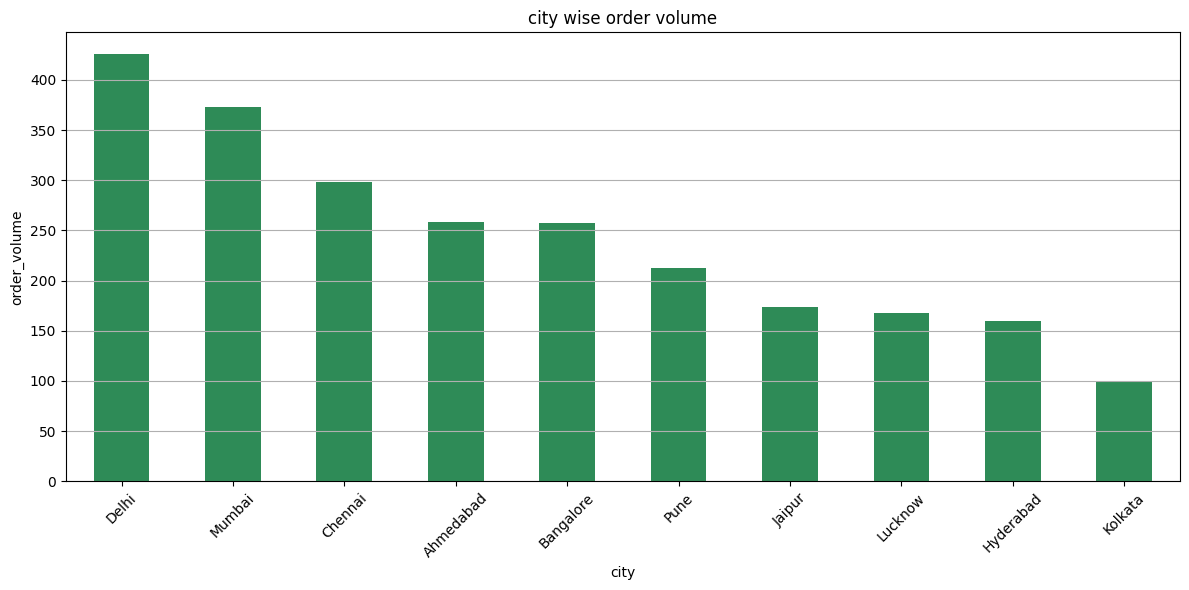

In [20]:
order_volume = df.groupby('city').size().sort_values(ascending=False)
plt.figure(figsize=(12,6))
order_volume.plot(kind = 'bar',color ='Seagreen')
plt.xlabel('city')
plt.ylabel('order_volume')
plt.title('city wise order volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

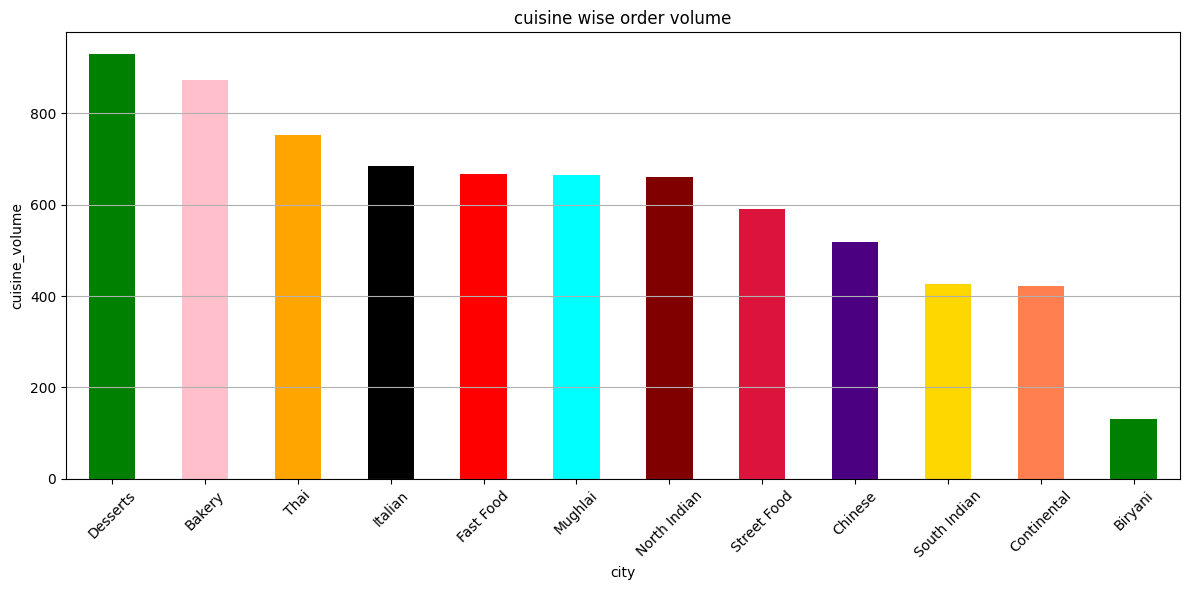

In [21]:
cuisine_volume=df.groupby('cuisine_type')['num_items'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
cuisine_volume.plot(kind = 'bar',color =['green','pink','orange','black','red','cyan','maroon','crimson','indigo','gold','coral'])
plt.xlabel('city')
plt.ylabel('cuisine_volume')
plt.title('cuisine wise order volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [22]:
df.groupby('cuisine_type')['order_value_inr'].sum().sort_values(ascending=False)

,order_value_inr
cuisine_type,
Desserts,132701.0
Bakery,124099.0
Thai,104393.0
Italian,99552.0
Mughlai,94772.0
North Indian,93506.0
Fast Food,92556.0
Street Food,83672.0
Chinese,72360.0


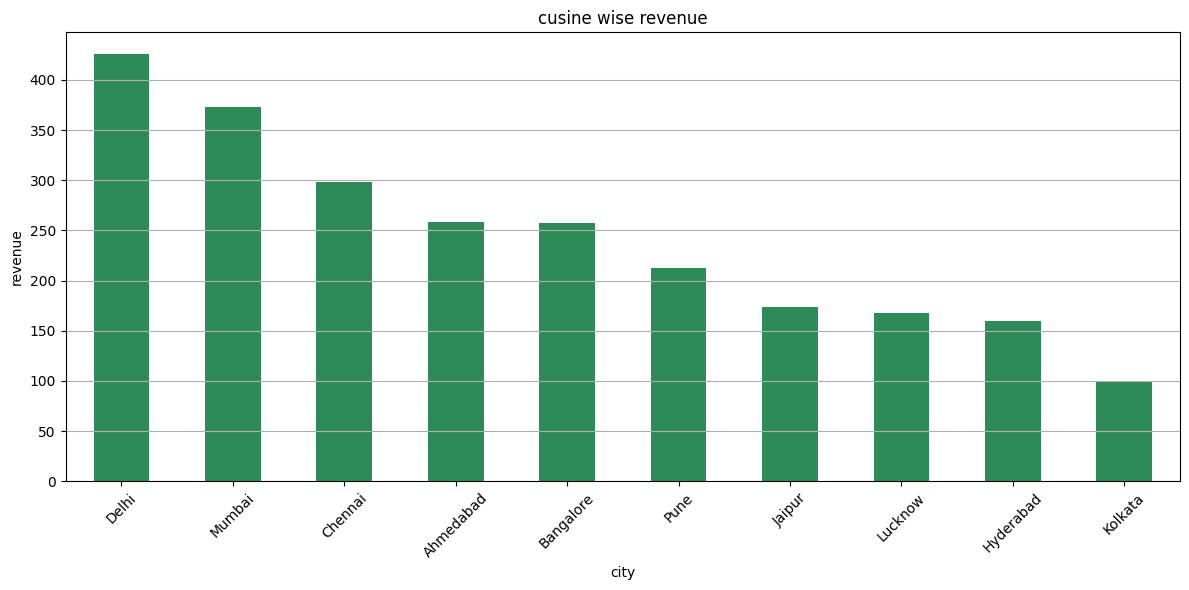

In [23]:
cuisine_wise_revenue =df.groupby('cuisine_type')['order_value_inr'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
order_volume.plot(kind = 'bar',color ='Seagreen')
plt.xlabel('city')
plt.ylabel('revenue')
plt.title('cusine wise revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

*this graph shows cuiwise revenue*
*Delhi generates the highest revenue, while Kolkata contributes the lowest. This city-wise analysis helps identify high-performing and underperforming markets*

## Discount % vs order value — does discount correlate with bigger orders?

In [24]:
df.groupby(['discount_percent','num_items'])['order_value_inr'].mean().reindex()

discount_percent  num_items
0                 1             150.632911
                  2             282.879310
                  3             421.580645
                  4             590.442478
                  5             659.215686
                  6             863.750000
                  7             940.000000
                  8            1273.333333
10                1             147.049180
                  2             302.260163
                  3             423.632812
                  4             551.910112
                  5             727.826087
                  6             973.277778
                  7             770.000000
                  8             750.000000
15                1             147.470588
                  2             289.000000
                  3             440.793893
                  4             551.200000
                  5             755.897436
                  6             704.166667
                  7            1006.666667
                  8             783.333333
20                1             137.901639
                  2             288.840000
                  3             414.383721
                  4             563.402985
                  5             742.777778
                  6             770.769231
                  7             990.000000
                  8             980.000000
                  9            1690.000000
25                1             153.054054
                  2             274.885246
                  3             410.450000
                  4             499.243902
                  5             659.583333
                  6             925.454545
                  7             940.000000
                  8             610.000000
30                1             133.041667
                  2             311.436364
                  3             431.812500
                  4             543.027778
                  5             768.235294
                  6             900.000000
                  7             840.000000
50                1             132.900000
                  2             278.176471
                  3             420.850000
                  4             640.909091
                  5             685.714286
                  6             460.000000
                  7              99.000000
                  8             640.000000
Name: order_value_inr, dtype: float64

/tmp/ipykernel_1590/3806699652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df,x = 'discount_percent',y = 'order_value_inr',palette='rainbow')


<Axes: xlabel='discount_percent', ylabel='order_value_inr'>

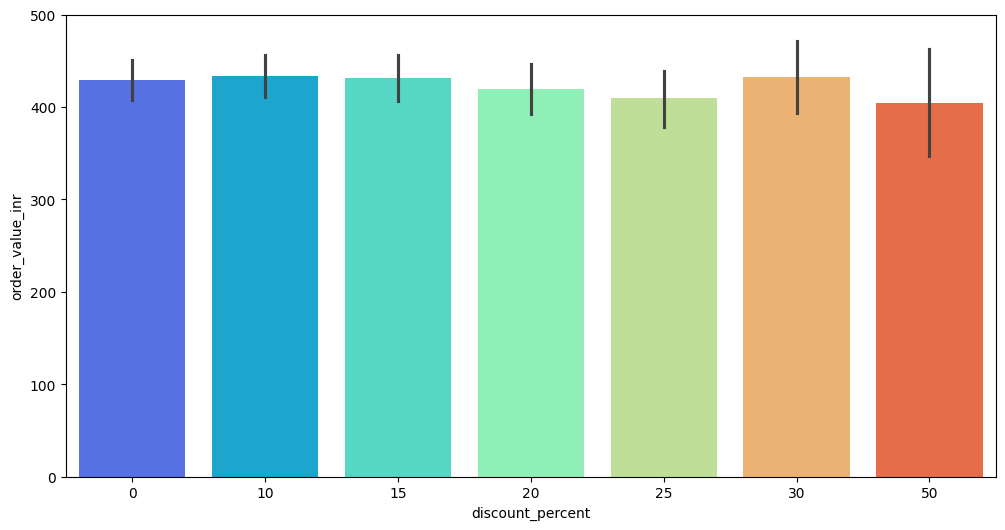

In [25]:
average_order_value_by_discount =df.groupby(['discount_percent','num_items'])['order_value_inr'].mean().reindex()
plt.figure(figsize=(12,6))
plt.ylim(0,500)
sns.barplot(data = df,x = 'discount_percent',y = 'order_value_inr',palette='rainbow')



# Delivery time vs customer rating — does slow delivery hurt ratings?


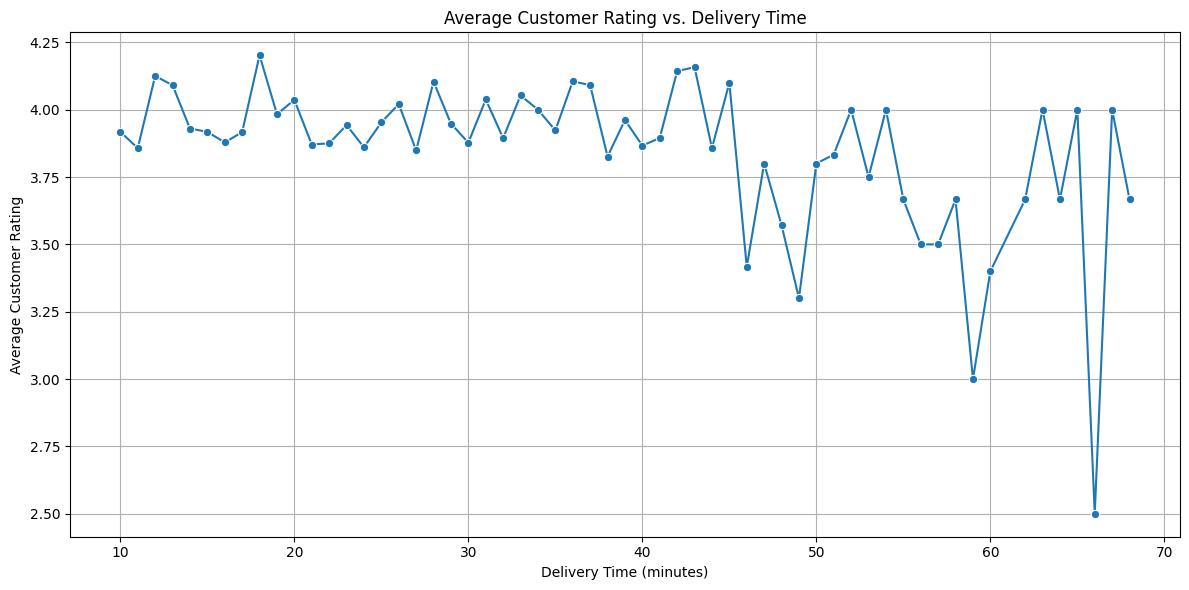

In [26]:
delivery_rating = df.groupby('delivery_time_mins')['customer_rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='delivery_time_mins', y='customer_rating', data=delivery_rating, marker='o')
plt.title('Average Customer Rating vs. Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Average Customer Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

regression target = order_value_inr

classification target = is_cancelled

## APPLYING MACHINE LEARNING

In [36]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

In [37]:

df.head(5)


,order_id,restaurant_id,restaurant_name,city,cuisine_type,order_date,order_time,customer_id,num_items,is_veg,...,discount_percent,distance_km,delivery_time_mins,payment_method,customer_rating,is_cancelled,order_datetime,month,day_in_week,hour
0,ORD00001,R0017,Urban Corner,Lucknow,Mughlai,2024-04-08,15:26,CUST0681,4,Non-Veg,...,20,6.8,32.0,Wallet,3.0,No,2024-04-08 15:26:00,April,Monday,15
1,ORD00002,R0039,Chai Treat,Pune,Fast Food,2024-07-26,11:35,CUST0854,3,Veg,...,10,3.0,26.0,UPI,3.0,No,2024-07-26 11:35:00,July,Friday,11
2,ORD00003,R0084,Punjabi Bites,Bangalore,South Indian,2024-06-13,14:29,CUST0453,4,Veg,...,0,9.6,37.0,Credit Card,4.0,No,2024-06-13 14:29:00,June,Thursday,14
3,ORD00004,R0102,Desi Kitchen,Pune,Desserts,2024-03-27,19:42,CUST0087,4,Veg,...,20,0.8,10.0,Debit Card,4.0,No,2024-03-27 19:42:00,March,Wednesday,19
4,ORD00005,R0097,Bombay Kitchen,Mumbai,Thai,2024-04-30,16:43,CUST0318,6,Veg,...,0,0.5,13.0,UPI,4.0,No,2024-04-30 16:43:00,April,Tuesday,16


In [38]:
REG_TARGET = "order_value_inr"
CLF_TARGET = "is_cancelled"
LEAKAGE_COLS = ['delivery_time_mins','customer_rating']
EXTRA_DROP = ['restaurant_name','	cuisine_type','city','restaurant_id','is_veg','discount_percent','']
print([c for c in df.columns])

['order_id', 'restaurant_id', 'restaurant_name', 'city', 'cuisine_type', 'order_date', 'order_time', 'customer_id', 'num_items', 'is_veg', 'order_value_inr', 'discount_percent', 'distance_km', 'delivery_time_mins', 'payment_method', 'customer_rating', 'is_cancelled', 'order_datetime', 'month', 'day_in_week', 'hour']


In [39]:
data = df.copy()
data.columns = data.columns.str.strip()
data = data.drop_duplicates()

data = data.dropna(subset=[REG_TARGET, CLF_TARGET])
data[REG_TARGET] = pd.to_numeric(data[REG_TARGET], errors="coerce")
data = data.dropna(subset=[REG_TARGET])

if data[CLF_TARGET].dtype == "object" or data[CLF_TARGET].dtype == "bool":
    pos = {"yes","true","1","y","cancelled","canceled"}
    data[CLF_TARGET] = data[CLF_TARGET].astype(str).str.strip().str.lower().isin(pos).astype(int)
else:
    data[CLF_TARGET] = data[CLF_TARGET].astype(int)


for c in list(data.columns):
    if any(k in c.lower() for k in ["date", "time", "timestamp"]) and data[c].dtype == "object":
        dt = pd.to_datetime(data[c], errors="coerce")
        if dt.notna().mean() > 0.6:
            data[f"{c}_year"] = dt.dt.year
            data[f"{c}_month"] = dt.dt.month
            data[f"{c}_day"] = dt.dt.day
            data[f"{c}_dow"] = dt.dt.dayofweek
            data[f"{c}_hour"] = dt.dt.hour
            data[f"{c}_is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)
            data = data.drop(columns=c)


id_like = [c for c in data.select_dtypes(include="object").columns
           if data[c].nunique() > 0.5 * len(data) or c.lower() == "id" or c.lower().endswith("_id")]
print("Auto-dropped (ID-like):", id_like)
data = data.drop(columns=id_like + [c for c in LEAKAGE_COLS + EXTRA_DROP if c in data.columns])

print(data.shape)
print("Cancel rate:", round(data[CLF_TARGET].mean()*100, 2), "%")

Auto-dropped (ID-like): ['order_id', 'restaurant_id', 'customer_id']
(2426, 17)
Cancel rate: 6.68 %


In [40]:
def make_preprocessor(X):
    num = X.select_dtypes(include=np.number).columns.tolist()
    cat = X.select_dtypes(exclude=np.number).columns.tolist()
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                               max_categories=20, sparse_output=False))]), cat),
    ])

**REGRESSION MODEL--> ORDER_VALUE_INR**

,Model,MAE,RMSE,R2
0,Ridge,136.402,190.962,0.455
1,Linear Regression,136.496,191.060,0.455
2,Random Forest,139.827,195.361,0.430
3,HistGradientBoosting,141.526,196.437,0.423


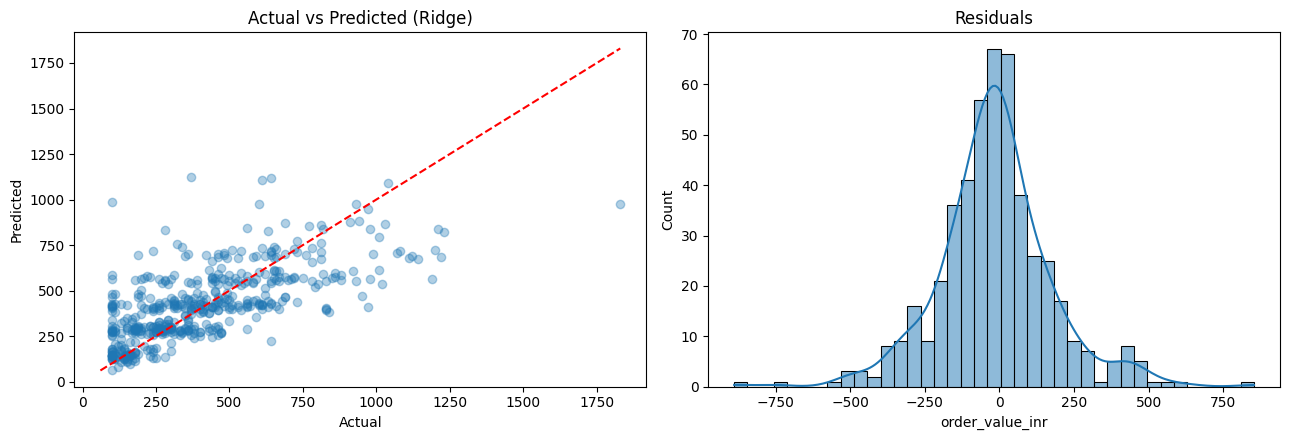

In [44]:
Xr = data.drop(columns=[REG_TARGET, CLF_TARGET])
yr = data[REG_TARGET]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

rows, reg_fitted = [], {}
for name, m in reg_models.items():
    pipe = Pipeline([("prep", make_preprocessor(Xr)), ("model", m)])
    pipe.fit(Xr_tr, yr_tr)
    p = pipe.predict(Xr_te)
    rows.append({"Model": name,
                 "MAE": mean_absolute_error(yr_te, p),
                 "RMSE": np.sqrt(mean_squared_error(yr_te, p)),
                 "R2": r2_score(yr_te, p)})
    reg_fitted[name] = pipe

reg_results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
display(reg_results.round(3))

best_reg = reg_results.loc[0, "Model"]
pred = reg_fitted[best_reg].predict(Xr_te)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(yr_te, pred, alpha=0.35)
lim = [min(yr_te.min(), pred.min()), max(yr_te.max(), pred.max())]
ax[0].plot(lim, lim, "r--"); ax[0].set_title(f"Actual vs Predicted ({best_reg})")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
sns.histplot(yr_te - pred, kde=True, ax=ax[1]); ax[1].set_title("Residuals")
plt.tight_layout(); plt.show()

**CLASSIFICATION MODEL--> IS_CANCELLED**

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.934,0.000,0.000,0.000,0.517
1,HistGradientBoosting,0.874,0.061,0.062,0.062,0.511
2,Logistic Regression,0.494,0.047,0.344,0.082,0.402



Best: Random Forest

               precision    recall  f1-score   support

Not Cancelled       0.93      1.00      0.97       454
    Cancelled       0.00      0.00      0.00        32

     accuracy                           0.93       486
    macro avg       0.47      0.50      0.48       486
 weighted avg       0.87      0.93      0.90       486



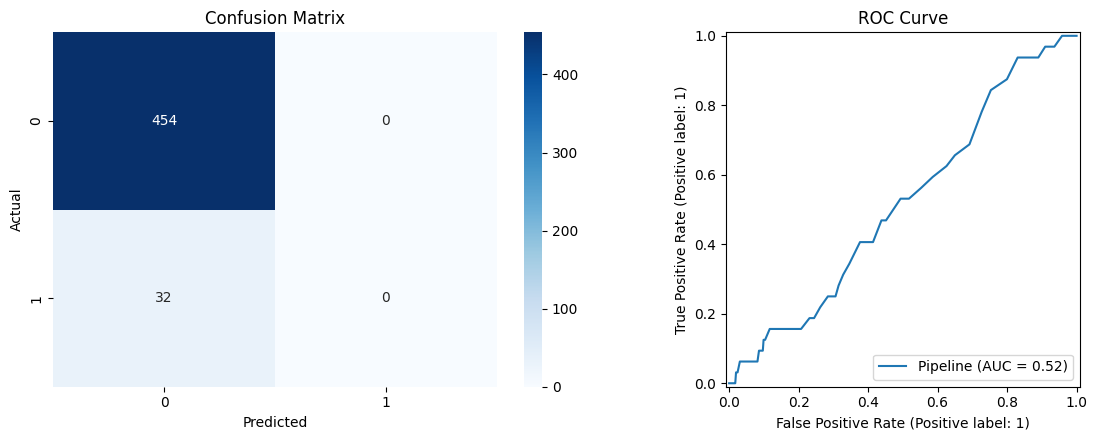

In [45]:
Xc = data.drop(columns=[CLF_TARGET])
yc = data[CLF_TARGET]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight="balanced", random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
}

rows, clf_fitted = [], {}
for name, m in clf_models.items():
    pipe = Pipeline([("prep", make_preprocessor(Xc)), ("model", m)])
    pipe.fit(Xc_tr, yc_tr)
    p = pipe.predict(Xc_te)
    proba = pipe.predict_proba(Xc_te)[:, 1]
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(yc_te, p),
                 "Precision": precision_score(yc_te, p, zero_division=0),
                 "Recall": recall_score(yc_te, p),
                 "F1": f1_score(yc_te, p),
                 "ROC-AUC": roc_auc_score(yc_te, proba)})
    clf_fitted[name] = pipe

clf_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(clf_results.round(3))

best_clf = clf_results.loc[0, "Model"]
pipe = clf_fitted[best_clf]
pred_c = pipe.predict(Xc_te)
print(f"\nBest: {best_clf}\n")
print(classification_report(yc_te, pred_c, target_names=["Not Cancelled", "Cancelled"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(confusion_matrix(yc_te, pred_c), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_estimator(pipe, Xc_te, yc_te, ax=ax[1]); ax[1].set_title("ROC Curve")
plt.tight_layout(); plt.show()

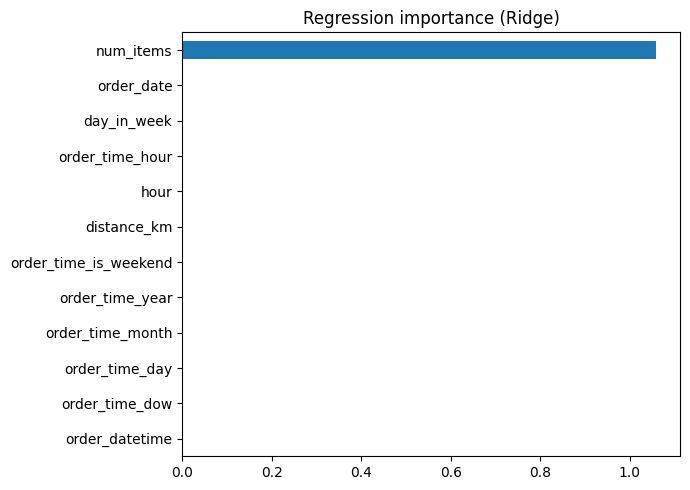

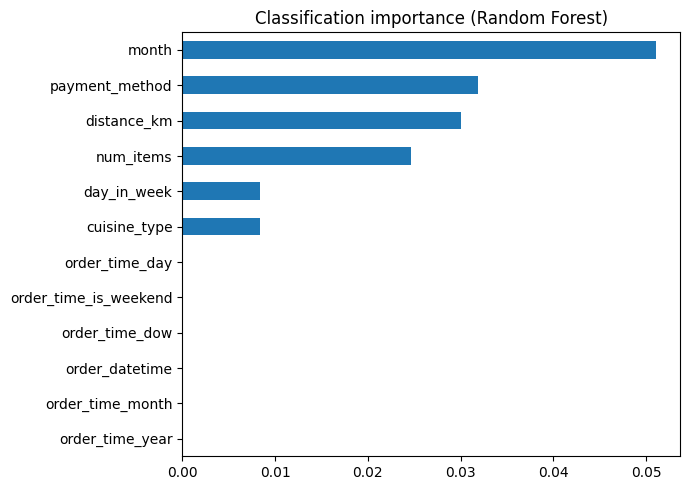

In [46]:
from sklearn.inspection import permutation_importance

def show_importance(pipe, X_te, y_te, scoring, title):
    r = permutation_importance(pipe, X_te, y_te, n_repeats=5, random_state=42, scoring=scoring, n_jobs=-1)
    imp = pd.Series(r.importances_mean, index=X_te.columns).sort_values().tail(12)
    imp.plot(kind="barh", figsize=(7, 5), title=title); plt.tight_layout(); plt.show()

show_importance(reg_fitted[best_reg], Xr_te, yr_te, "r2", f"Regression importance ({best_reg})")
show_importance(clf_fitted[best_clf], Xc_te, yc_te, "roc_auc", f"Classification importance ({best_clf})")